# 9.10 信心和正確率對得上嗎？


四題報告信心0.55、0.65、0.85、0.95，按真值判為對、錯、對、錯。平均信心0.75，實際正確率0.5；如果把機率當長期把握，這組偏高了。

按信心區間分組、比每組平均信心和正確率，叫可靠度分箱。兩箱[0,0.5)與[0.5,1]，四題都在高箱；左端包含，最後一箱連1也包含。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

In [2]:
import torch
from tiny_perceptron.alignment import reliability_bins

confidence = torch.tensor([0.55, 0.65, 0.85, 0.95])
correct = torch.tensor([1, 0, 1, 0])
bins = reliability_bins(confidence, correct, bins=2)
for row in bins:
    print(
        "區間",
        row["left"],
        row["right"],
        "筆數",
        row["count"],
        "信心",
        round(row["confidence"], 2),
        "正確率",
        row["accuracy"],
    )
ece = sum(row["count"] / len(confidence) * abs(row["accuracy"] - row["confidence"]) for row in bins)
print("平均校準差", round(ece, 2))

區間 0.5 1.0 筆數 4 信心 0.75 正確率 0.5
平均校準差 0.25


輸入四筆信心與對應正確標記。專案工具`reliability_bins`把同一區間的筆數、平均信心、正確率整理成字典；沒有樣本的箱不會出現在結果裡。因此只輸出0.5到1.0一箱，筆數4、信心0.75、正確率0.5。這不是有兩箱就必須有兩行；我們沒有低信心樣本。

最後的式子算每箱信心與正確率差多少，取絕對值，再乘該箱筆數佔總數的比例，加總得到0.25。英文ECE是Expected Calibration Error，在這裡可讀成按樣本量加權的校準差。只有一箱，所以權重4/4=1，差即0.75−0.5。若畫橫軸信心、縱軸正確率的圖，這個點在(0.75,0.5)，低於理想的相等線，顯示過度自信。

圖中點(0.75,0.5)在相等線下方，表示本組過度自信，不會把每筆預測改成0.5。四題只夠解釋計算，細箱可能被一兩題左右，分箱改變也會改ECE。


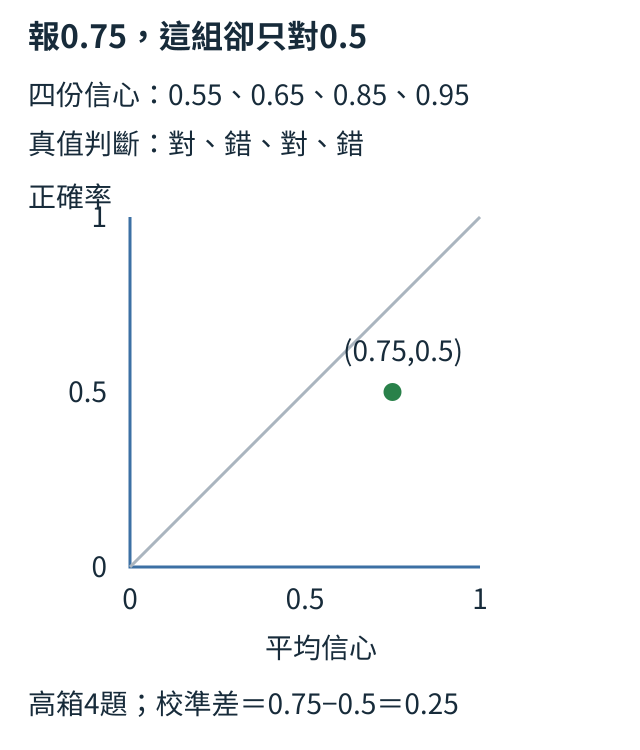

In [3]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-09-10-calibration-bins.svg")))

校準溫度T是一個正數設定：先把各候選的原始分數除以T，再用[1.7的softmax](https://birdhackor.github.io/tiny-perceptron-vlm/1.7.html)轉成機率。T=1維持原尺度；T較小讓原先較高分的候選更突出，較大則讓機率較平均，不會交換候選分數的高低次序。選T應在驗證集，固定後再測新題。[Guo等人的方法](https://proceedings.mlr.press/v70/guo17a.html)調整機率尺度，不增加分類知識；驗證最好也不保證測試更可靠，原小模型對照見補充。

練習新增信心0.25且答對的一筆，兩個tensor都要各加一個值，先預測低箱新增一筆、高箱仍四筆。低箱平均信心0.25、正確率1，ECE變成(1/5)×0.75+(4/5)×0.25=0.35。執行核對，並解釋為什麼這個新樣本讓整體差變大：它在低信心處表現得比報告更好，不是出現了新錯答。

<details>
<summary>補充：實作約定與原始紀錄</summary>

我們已對[10.5與12.8的已訓練分類器](https://github.com/birdhackor/tiny-perceptron-vlm/blob/main/docs/course-experiments/results/encoders.json)做一次實測。選溫度用的是分類交叉熵，也就是把標準答案機率轉成猜錯代價，再對題目平均；真值機率越低，代價越大。專案使用負自然對數來轉換，例如真值機率0.8的代價約0.2231，機率0.2的代價約1.6094，算例可回看[1.8](https://birdhackor.github.io/tiny-perceptron-vlm/1.8.html)。這個量會看報給真值的機率，不只計算最高候選是否答對。

各分類器先在驗證集比較溫度0.5、0.75、1、1.5、2、3、5，選平均分類交叉熵最低者，再固定設定測最後留出題；測試答案沒有參與選溫。這是[Guo等人提出的正溫度校準](https://proceedings.mlr.press/v70/guo17a.html)的固定網格教學近似，不是連續尋找最佳溫度。兩個分類器都選0.5，這次使機率更集中：最高候選的機率更高，其餘候選的機率總和更低。這與常見的「提高溫度降低過度自信」方向不同；若驗證題原本就選對，提高真值機率可以降低上述代價，方向必須由驗證數字決定。

正式報告使用五個等寬信心箱，從[0,0.2)到[0.8,1]，空箱也保存。除ECE外，另算Brier分數：把每個候選機率與標準答案的0或1逐項相減、平方、加總，再對題目平均，越小越好。例如真值是high，卻報low為0.8、high為0.2，這一題是0.8²+(0.2−1)²=1.28。本次採候選平方差的總和，沒有再除候選數，讀其他報告時應核對定義。

| 最後測試 | 溫度 | 答對／題數 | ECE | Brier |
| --- | ---: | ---: | ---: | ---: |
| 六類合成圖片，原始 | 1 | 6/6 | 0.02858 | 0.001485 |
| 同批圖片，校準後 | 0.5 | 6/6 | 0.000572 | 0.000000859 |
| 高低單音，原始 | 1 | 11/14 | 0.13186 | 0.20207 |
| 同批單音，校準後 | 0.5 | 11/14 | 0.14154 | 0.25337 |

圖片這六題的兩項誤差都下降，音訊卻相反。音訊驗證8/8全對，降低溫度幾乎使每題都接近信心1；最後測試含較靠近300Hz界線的新頻率，出現三道錯題。平均信心由0.8796升到0.9273，正確率仍11/14約0.7857，分類交叉熵也由0.2776升至0.3465。像只在熟悉路段估計自己的駕駛把握，換到另一段路卻仍照樣加大把握；驗證上的最佳設定沒有保證新題更可靠。這14題、六張圖與五個箱都很小，不能據此宣布某種校準普遍有效或無效，更不能轉成安全回應的保證。

下圖只取同一批14段測試單音。藍條長度是平均信心，紫色虛線位置是固定的11/14正確率；兩張卡用相同的0到100%尺度，所以校準後條更長、虛線卻沒有移動。可以把它想成答同一張考卷的人沒有改答案，只把「我有把握」喊得更大聲。下方兩項誤差都增加，提醒我們增加把握沒有增加答對題數；圖上也保留溫度是在八段驗證錄音選的，不能把測試變差偷偷改成另一個溫度再報最好結果。

條末端與虛線的距離只比較兩個整體平均，不能從這段距離抄出ECE。原始整體差約0.87960−0.78571=0.09388，ECE卻是0.13186，因為它先逐箱取差的絕對值，再按箱的筆數加權，不讓不同箱的偏差互相抵消；Brier又是逐題、逐候選的平方差，兩者都要回到上面的定義計算。


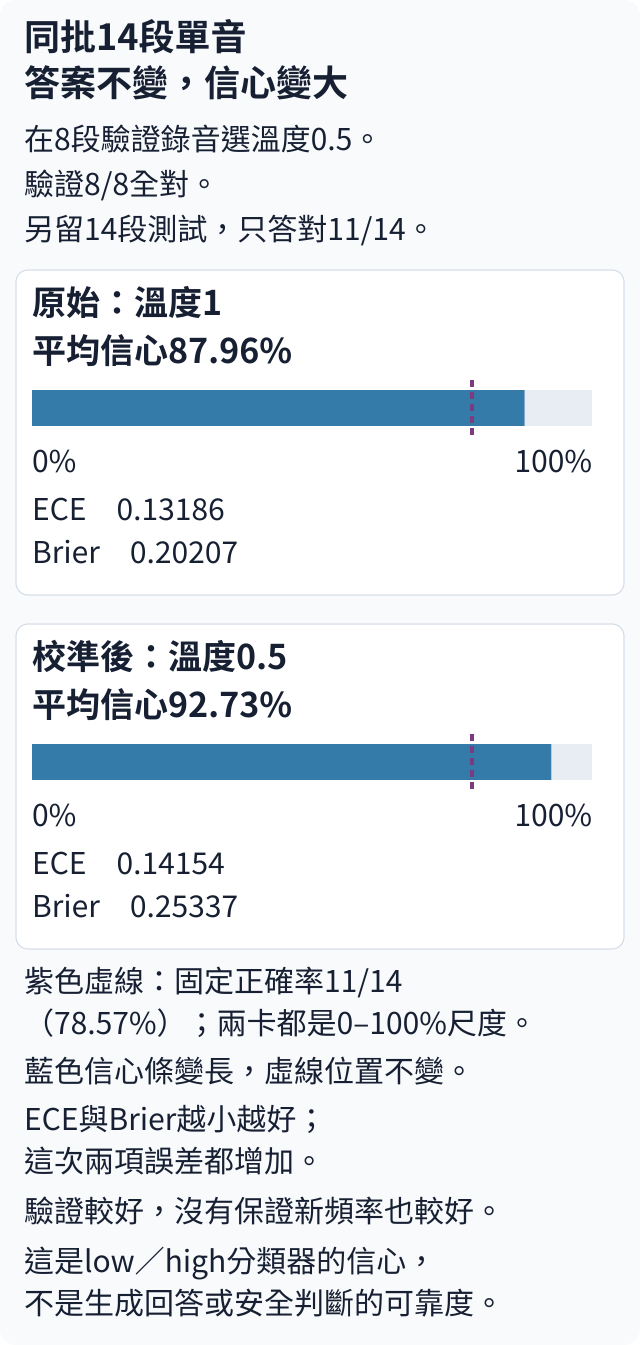

In [4]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/audio_calibration_test.svg")))

短程式沿用本課工具與原計算語義。安裝、長訓練與重做操作見[訓練配方](https://birdhackor.github.io/tiny-perceptron-vlm/training.html)，不需要先完成長配方才能閱讀這個例子。

</details>
